<a href="https://colab.research.google.com/github/np-helios/NishthaPandey_23fe10cse00774/blob/main/Lung_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import kagglehub

path = kagglehub.dataset_download("dhrubangtalukdar/lung-cancer-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 86.9k/86.9k [00:00<00:00, 17.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dhrubangtalukdar/lung-cancer-prediction-dataset/versions/1


In [3]:
import os
os.listdir(path)

['lung_cancer.csv']

In [4]:
df = pd.read_csv(f"{path}/lung_cancer.csv")
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

In [6]:
df.describe()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,8.822200,6.685600,6.249000,0.347600,64.278800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,11.651598,9.032888,9.964901,0.476256,19.479809,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,18.000000,14.000000,10.000000,1.000000,78.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,52.000000,44.000000,60.000000,1.000000,130.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


In [7]:
df.columns

Index(['age', 'gender', 'education_years', 'income_level', 'smoker',
       'smoking_years', 'cigarettes_per_day', 'pack_years', 'passive_smoking',
       'air_pollution_index', 'occupational_exposure', 'radon_exposure',
       'family_history_cancer', 'copd', 'asthma', 'previous_tb',
       'chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'bmi',
       'oxygen_saturation', 'fev1_x10', 'crp_level', 'xray_abnormal',
       'exercise_hours_per_week', 'diet_quality', 'alcohol_units_per_week',
       'healthcare_access', 'lung_cancer_risk'],
      dtype='object')

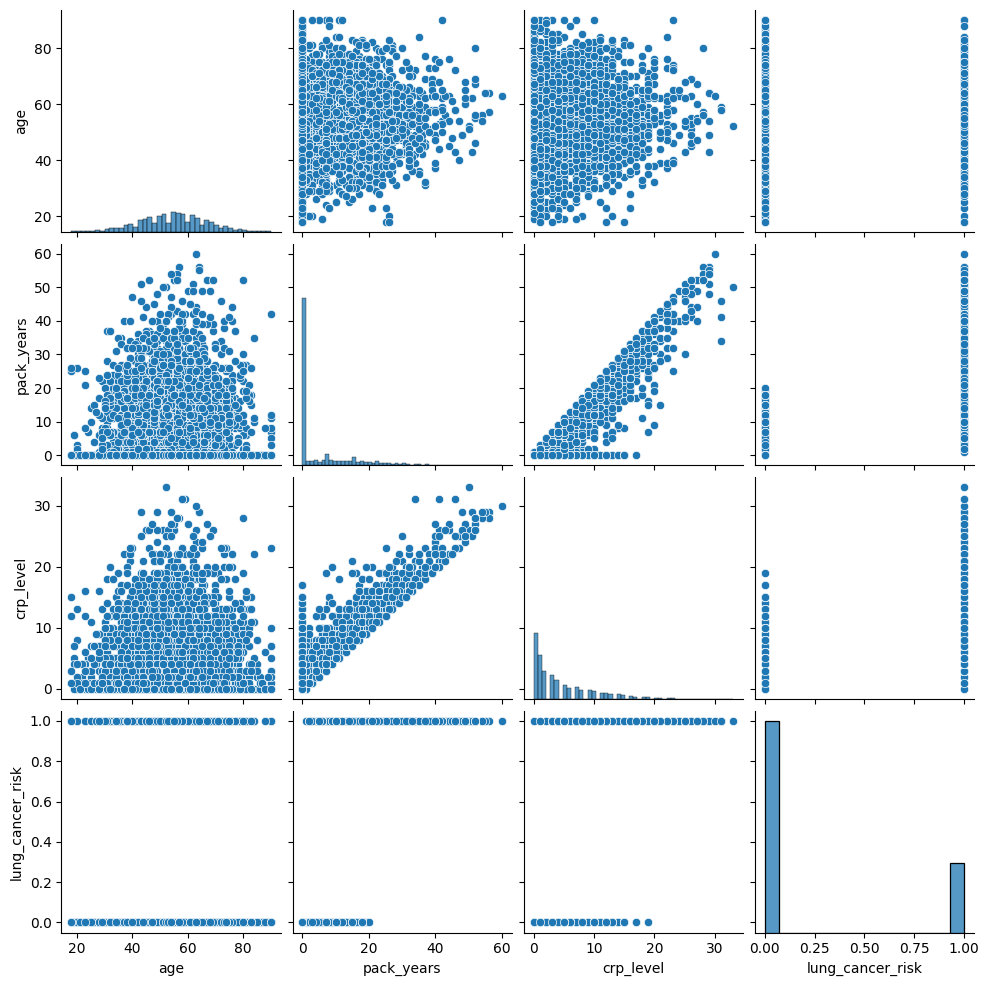

In [8]:
sns.pairplot(df[['age', 'pack_years', 'crp_level', 'lung_cancer_risk']])

In [9]:
print(df.isnull().sum())

age                        0
gender                     0
education_years            0
income_level               0
smoker                     0
smoking_years              0
cigarettes_per_day         0
pack_years                 0
passive_smoking            0
air_pollution_index        0
occupational_exposure      0
radon_exposure             0
family_history_cancer      0
copd                       0
asthma                     0
previous_tb                0
chronic_cough              0
chest_pain                 0
shortness_of_breath        0
fatigue                    0
bmi                        0
oxygen_saturation          0
fev1_x10                   0
crp_level                  0
xray_abnormal              0
exercise_hours_per_week    0
diet_quality               0
alcohol_units_per_week     0
healthcare_access          0
lung_cancer_risk           0
dtype: int64


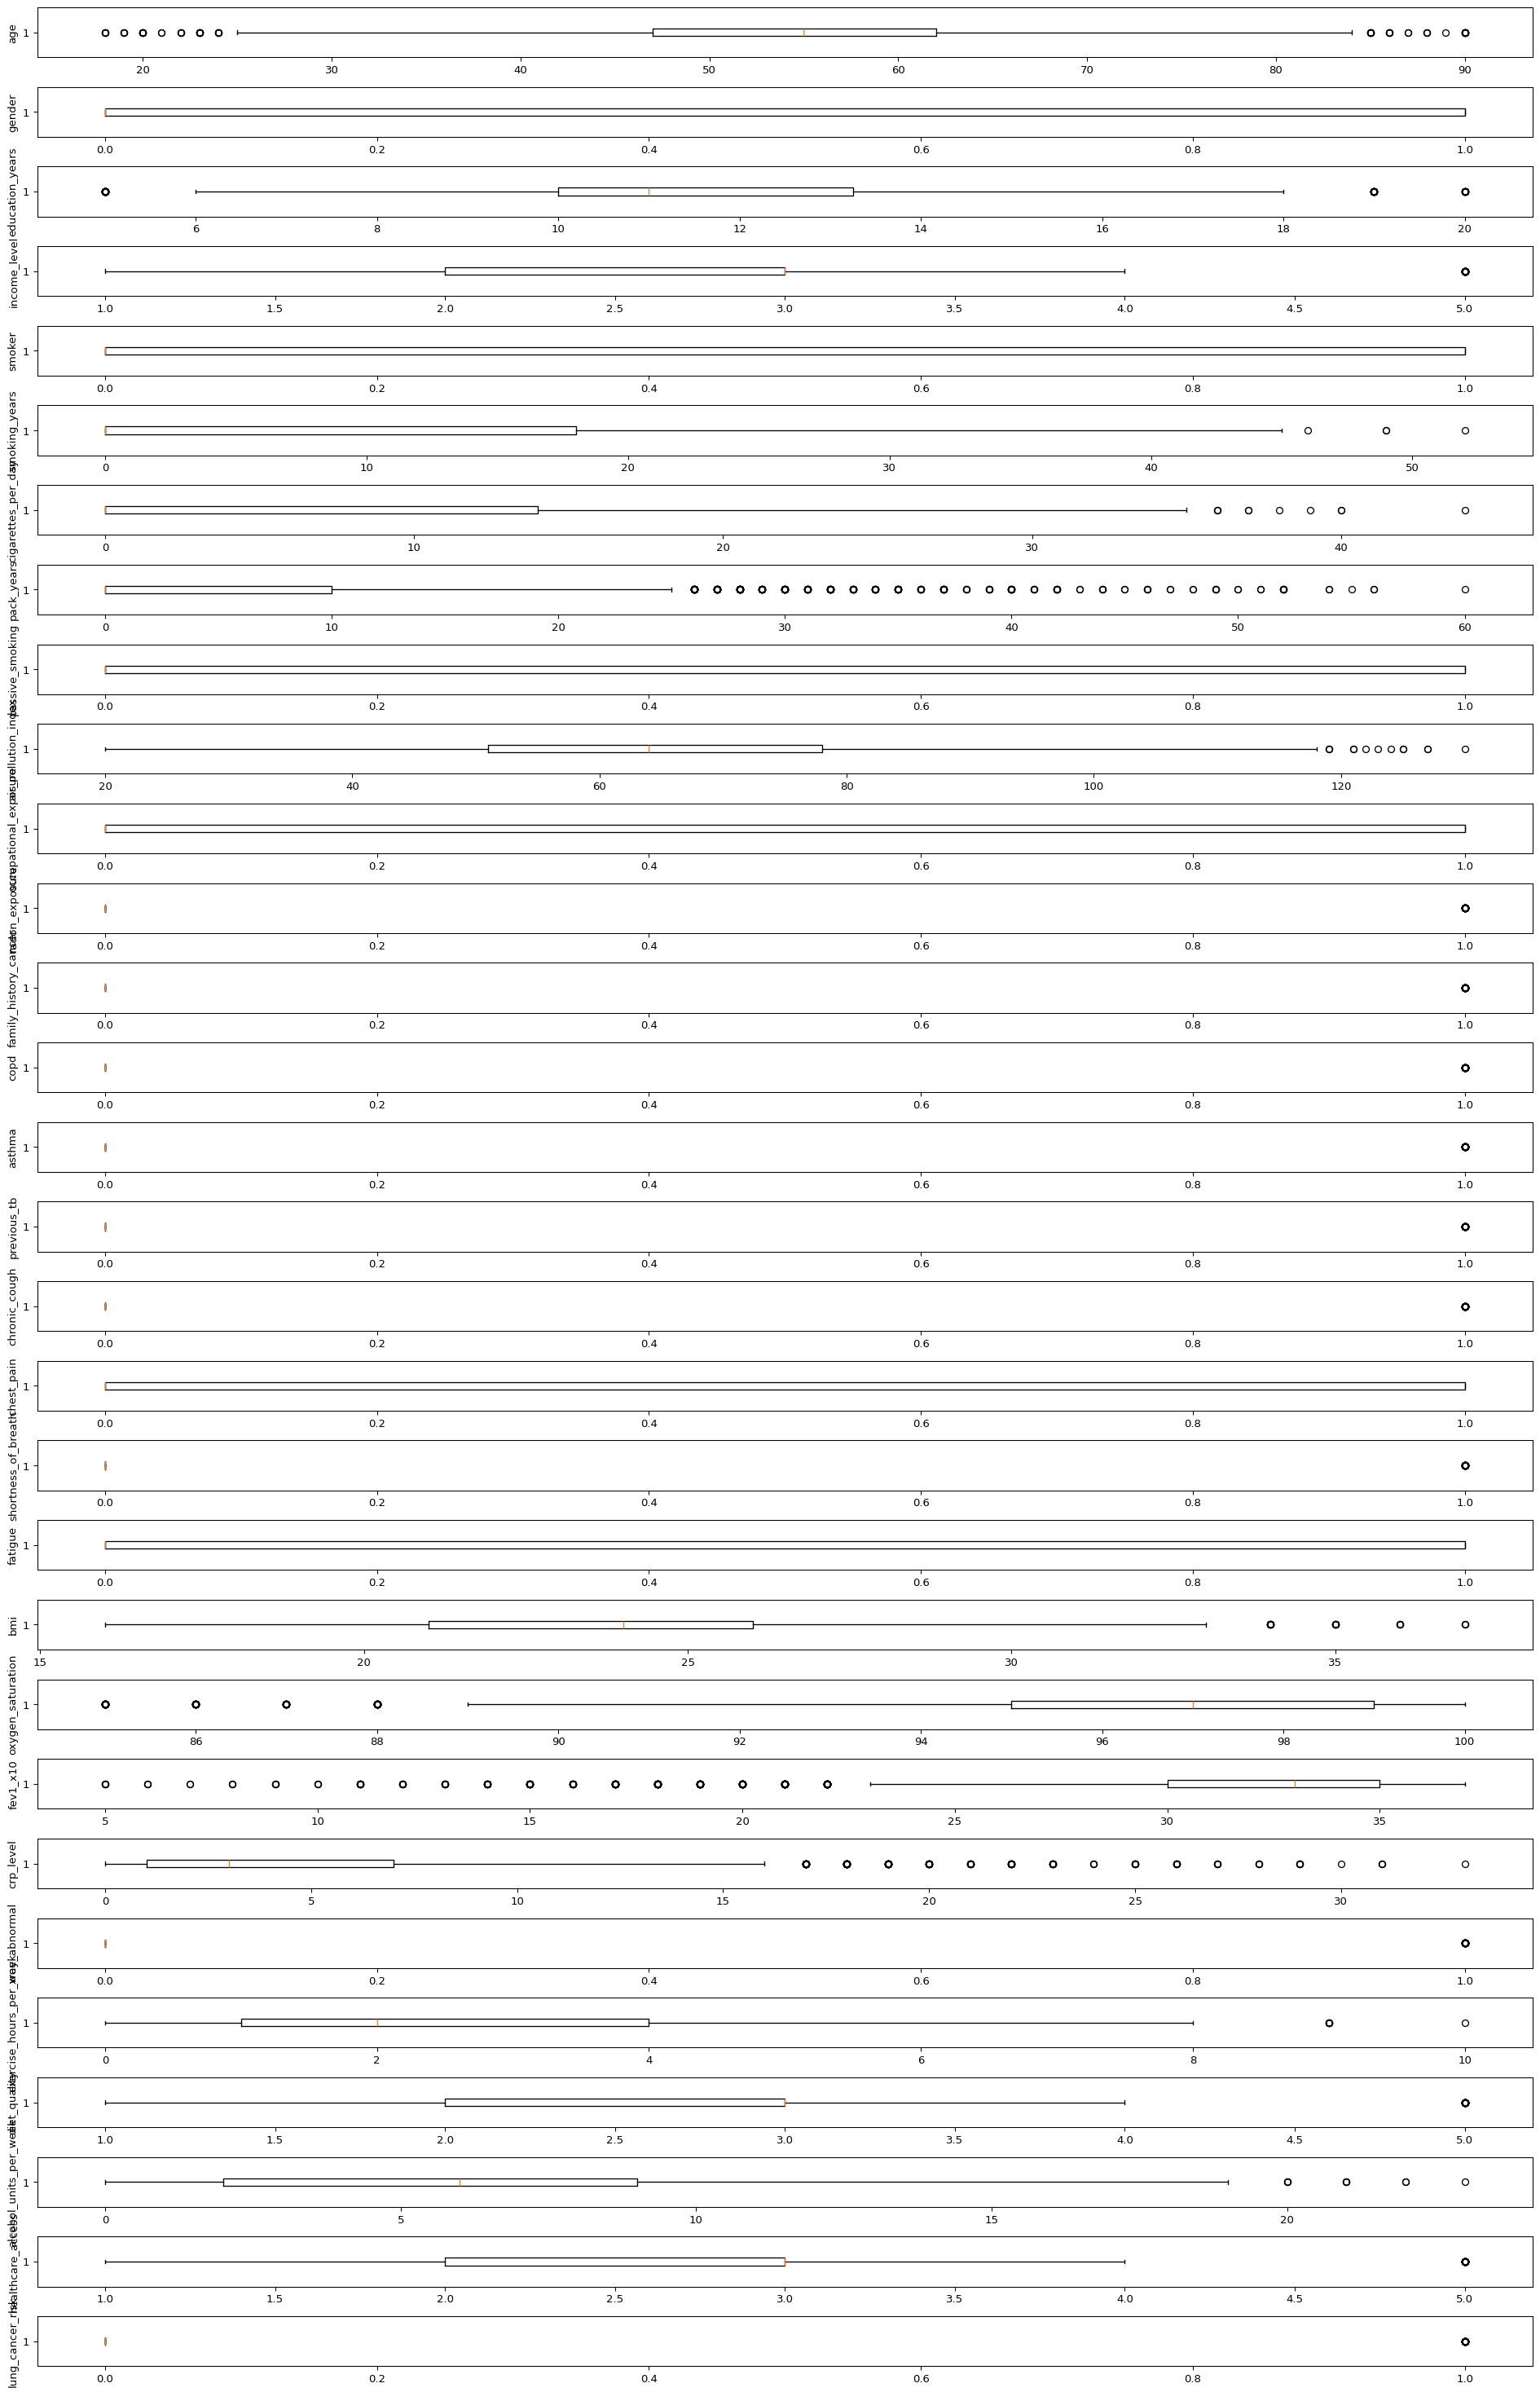

In [10]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(20, 31), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [11]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())



age
[60 53 62 73 52 64 49 61 57 32 34 48 42 58 44 38 72 55 37 56 41 59 47 51
 77 54 40 31 39 63 46 67 33 50 66 71 23 45 65 84 68 81 43 36 70 35 87 90
 82 80 30 76 18 74 29 69 79 78 27 75 25 28 22 85 86 20 83 24 19 26 88 21
 89]

gender
[1 0]

education_years
[20 12 15 13 10 11 14  8 17 16  6  9  7 18  5 19]

income_level
[2 4 3 1 5]

smoker
[1 0]

smoking_years
[16  0  9 29 33 20 12 25 13 15 17 18 21 26 19  5 45 31 11 24 35 34 40 22
 10 28 23 36 32  8 37  7  4 30 44 14 39 27 38  6  1 41  3 43  2 42 49 46
 52]

cigarettes_per_day
[15  0 29 18 17 12 19 11  9 21  8 25 16 14 24  3  4  5 27 23 30  6 22 13
 20 26 35 36 10 32  7 28  2  1 33 37 31 40 38 39 44 34]

pack_years
[12  0 13 26 28 15  8  7 30 17 36 20 10  4  3  9 37  5 14 24  6 32 34 29
 16 38 25 18 22 31 11 27 50 35 56 33 21  1  2 19 42 44 52 23 40 41 49 51
 45 54 55 48 39 43 46 47 60]

passive_smoking
[0 1]

air_pollution_index
[ 71  66  69  47  94  55  88 127  62 105  59  80  74  52  76  89 102  54
  67  61  42  43  57  34  64  6

In [12]:
# q1, q3 = np.percentile(df['pack_years'], [25, 75])
# iqr = q3 - q1
# lower = q1 - 1.5 * iqr
# upper = q3 + 1.5 * iqr
# clean_df = df[(df['pack_years'] >= lower) & (df['pack_years'] <= upper)]

In [13]:
# continuous_cols = [
#     'age', 'pack_years', 'air_pollution_index',
#     'bmi', 'oxygen_saturation', 'fev1_x10',
#     'crp_level', 'alcohol_units_per_week'
# ]

# outlier_counts = {}

# for col in continuous_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < lower) | (df[col] > upper)]
#     outlier_counts[col] = len(outliers)

# pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count']) \
#   .sort_values(by='Outlier_Count', ascending=False)


In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

X = df.drop('lung_cancer_risk', axis=1)
y = df['lung_cancer_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


continuous_cols = [
    'age', 'pack_years', 'air_pollution_index',
    'bmi', 'oxygen_saturation', 'fev1_x10',
    'crp_level', 'alcohol_units_per_week'
]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_cols)
    ],
    remainder='passthrough'
)


X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Done scaling ")

Done scaling 


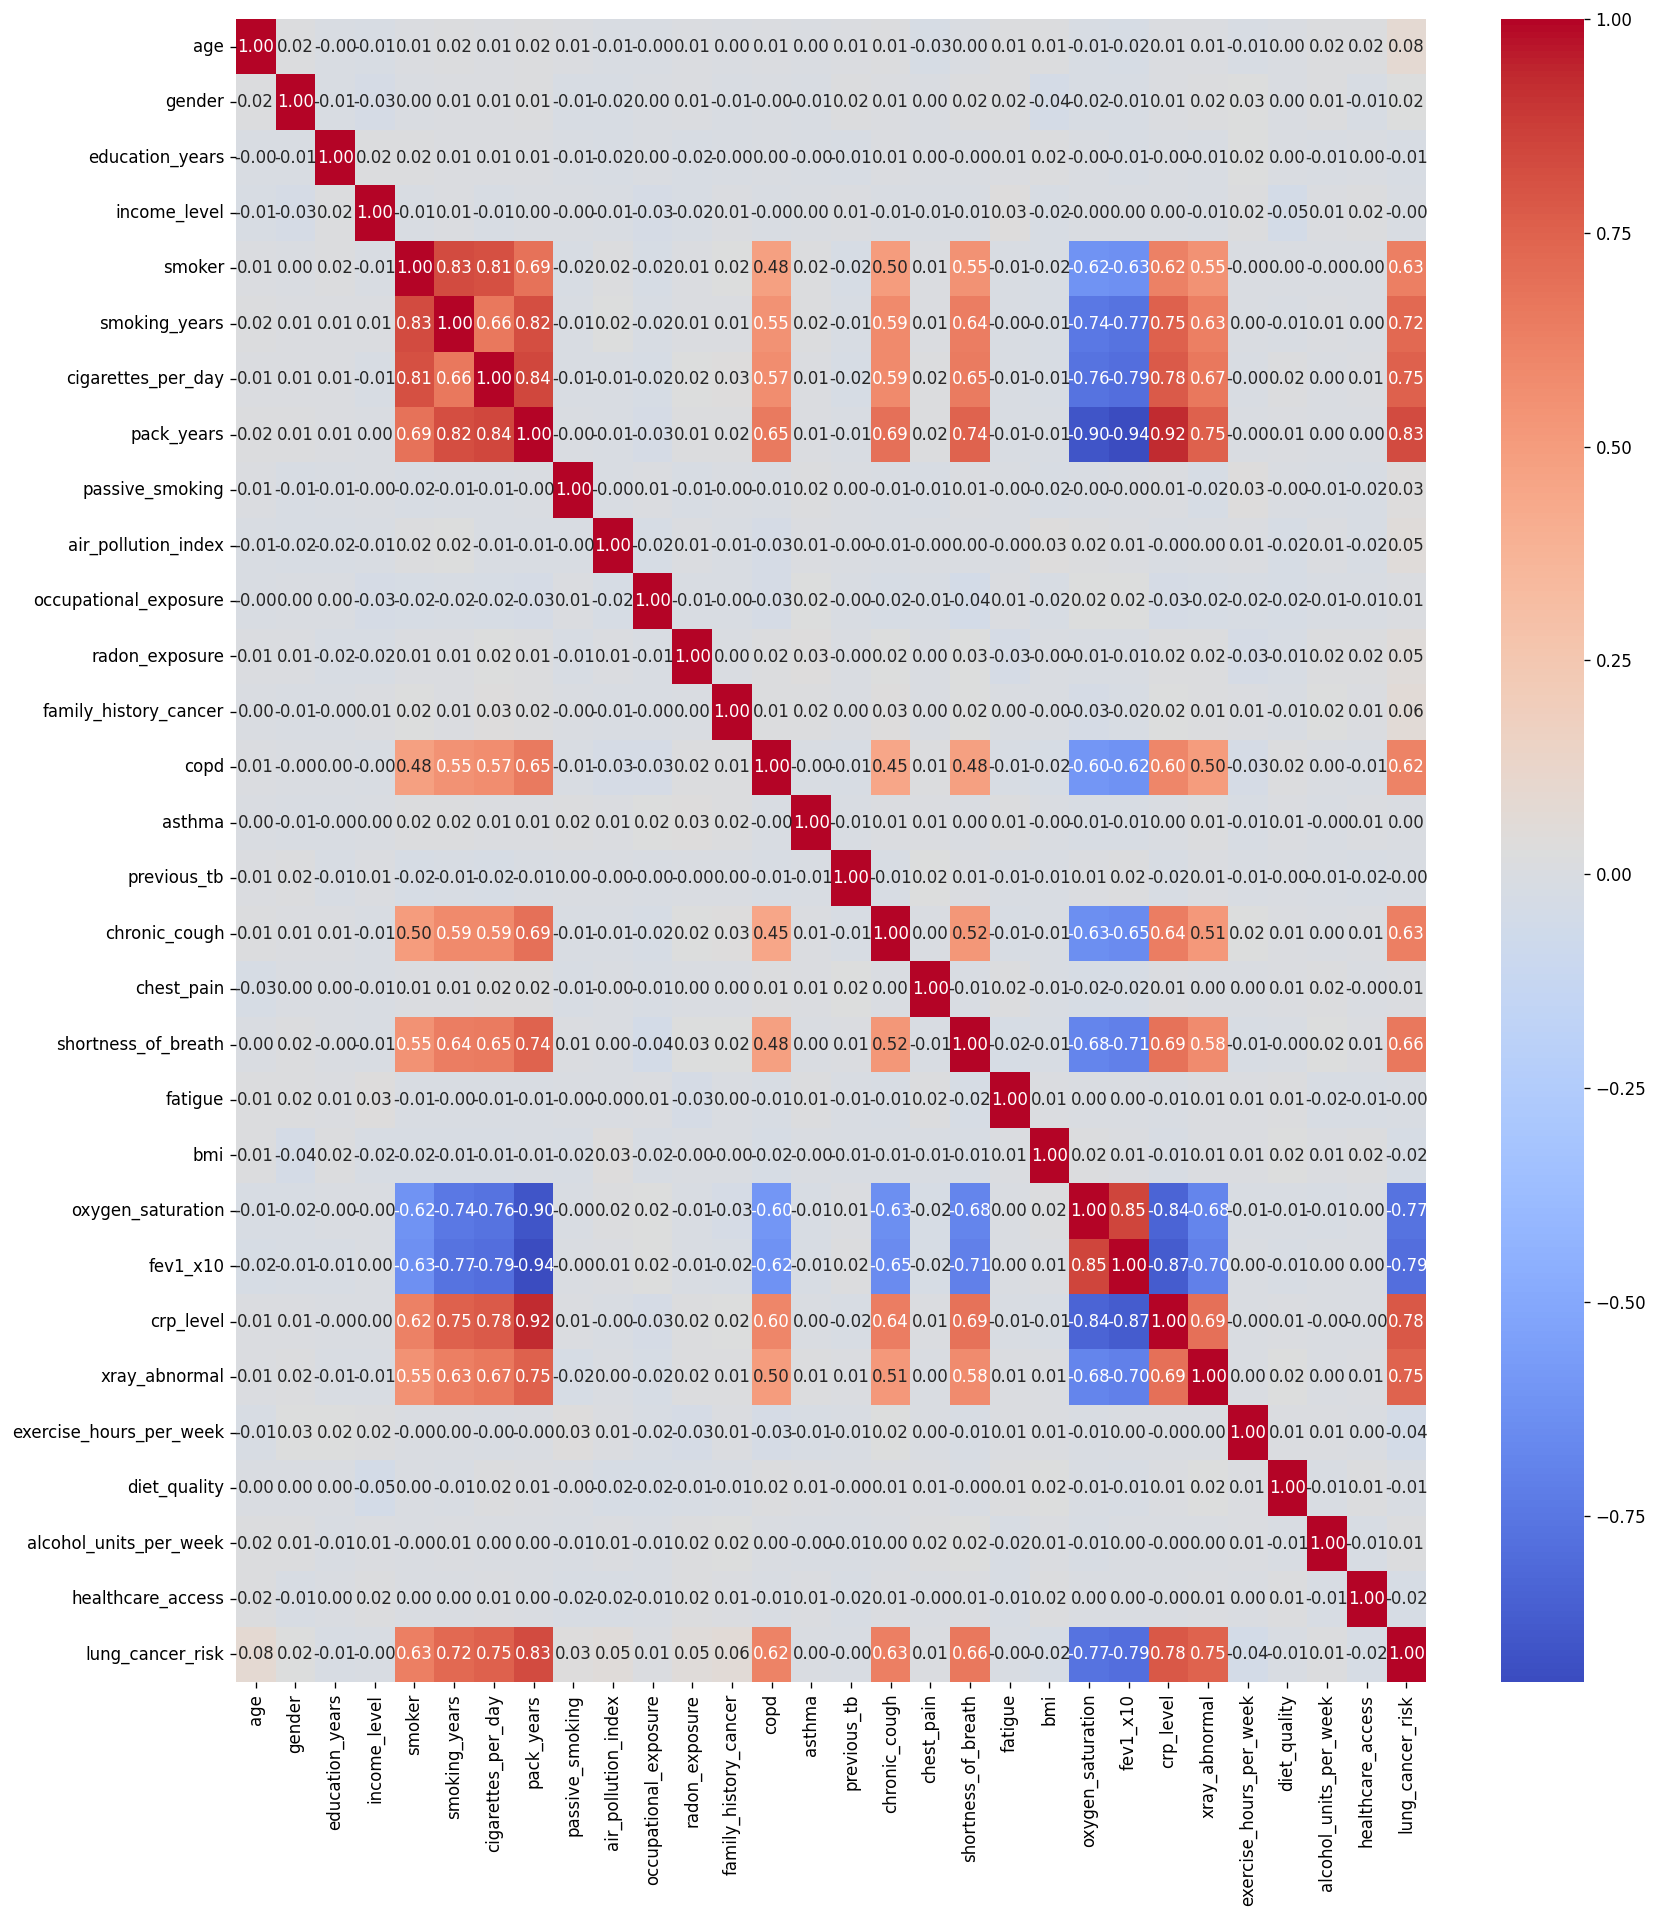

pack_years                 1.000000
crp_level                  0.924257
cigarettes_per_day         0.844534
lung_cancer_risk           0.830688
smoking_years              0.820470
xray_abnormal              0.749515
shortness_of_breath        0.743815
chronic_cough              0.689500
smoker                     0.686671
copd                       0.654711
family_history_cancer      0.019885
chest_pain                 0.019837
age                        0.015881
radon_exposure             0.014758
gender                     0.012938
asthma                     0.011069
diet_quality               0.009008
education_years            0.005461
alcohol_units_per_week     0.004502
healthcare_access          0.003115
income_level               0.001793
passive_smoking           -0.000327
exercise_hours_per_week   -0.001692
fatigue                   -0.006611
air_pollution_index       -0.009476
bmi                       -0.009652
previous_tb               -0.010085
occupational_exposure     -0

In [15]:
corr = df.corr()
plt.figure(figsize=(16, 18), dpi=120)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['pack_years'].sort_values(ascending=False))

In [16]:
# X = df.drop(columns=['crp_level'])
# y = df['crp_level']

In [17]:
# df = df.drop(columns=[
#     'smoking_years',
#     'cigarettes_per_day',
#     'smoker'
# ])


In [18]:
# df['pack_years'] = np.log1p(df['pack_years'])
# df['crp_level'] = np.log1p(df['crp_level'])
# df['alcohol_units_per_week'] = np.log1p(df['alcohol_units_per_week'])


In [19]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_normalized = scaler.fit_transform(X)
# print(X_normalized[:5])

In [20]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_standardized = scaler.fit_transform(X)
# print(X_standardized[:5])

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.989

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       746
           1       0.99      0.96      0.98       254

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:
 [[744   2]
 [  9 245]]


In [23]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [24]:
threshold = 0.3

y_pred_custom = (y_prob > threshold).astype(int)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

Accuracy: 0.993

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       746
           1       0.97      1.00      0.99       254

    accuracy                           0.99      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:
 [[739   7]
 [  0 254]]


AUC Score: 0.9997519579489561


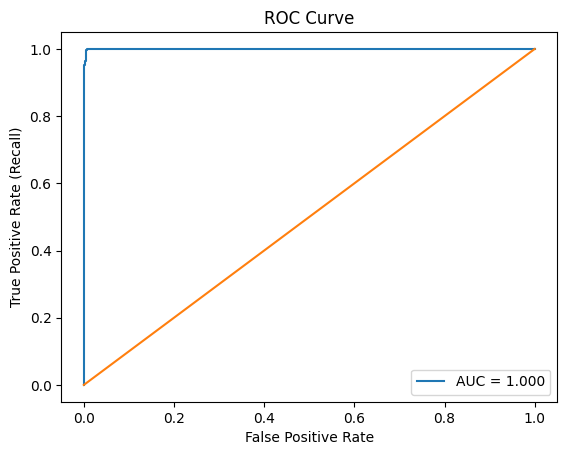

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1])  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

target_col = "lung_cancer_risk"

X = df.drop(columns=[target_col])
y = df[target_col]

# Better than a single train/test split: keep a validation set for threshold tuning
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, stratify=y_train_val, random_state=42
)

feature_names = X.columns.tolist()

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)
X_train_val_scaled = preprocessor.fit_transform(X_train_val)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (3200, 29)
Validation: (800, 29)
Test: (1000, 29)


In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    cv_auc = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    ).mean()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "CV ROC-AUC": cv_auc
    }

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42
    ),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    row = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(row)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(
    ["ROC-AUC", "Accuracy", "F1 Score"], ascending=False
).reset_index(drop=True)

baseline_acc = results_df.loc[results_df["Model"] == "Logistic Regression", "Accuracy"].iloc[0]
baseline_f1 = results_df.loc[results_df["Model"] == "Logistic Regression", "F1 Score"].iloc[0]

results_df["Accuracy Gain vs Logistic"] = results_df["Accuracy"] - baseline_acc
results_df["F1 Gain vs Logistic"] = results_df["F1 Score"] - baseline_f1

results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC,Accuracy Gain vs Logistic,F1 Gain vs Logistic
0,Logistic Regression,0.994,0.9880,0.9880,0.9880,0.9999,0.9996,0.000,0.0000
1,SVM,0.983,0.9793,0.9518,0.9654,0.9987,0.9984,-0.011,-0.0226
2,Gradient Boosting,0.972,0.9585,0.9277,0.9429,0.9944,0.9961,-0.022,-0.0451
3,Extra Trees,0.965,0.9421,0.9157,0.9287,0.9944,0.9943,-0.029,-0.0592
4,Random Forest,0.965,0.9421,0.9157,0.9287,0.9936,0.9940,-0.029,-0.0592
5,KNN,0.957,0.9640,0.8594,0.9087,0.9876,0.9857,-0.037,-0.0792
6,Decision Tree,0.949,0.9267,0.8635,0.8940,0.9699,0.9789,-0.045,-0.0940


/tmp/ipykernel_7889/678867134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y="Model", x="Accuracy", palette="crest")


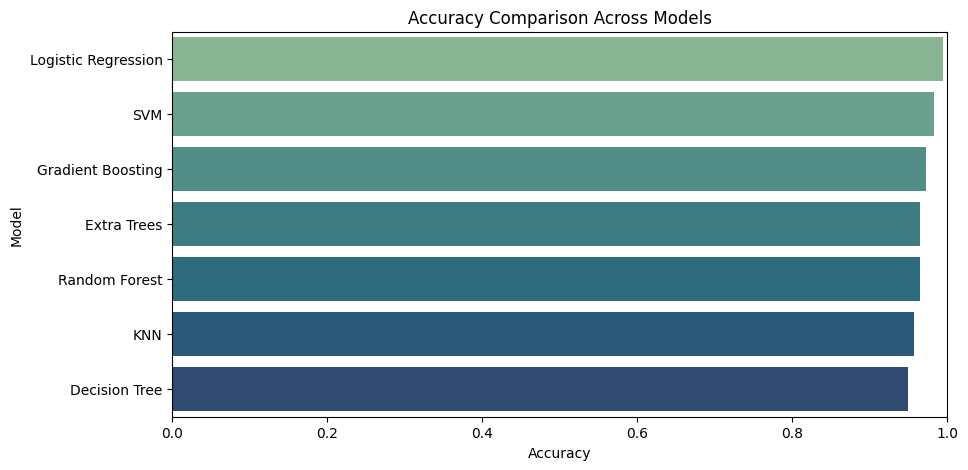

/tmp/ipykernel_7889/678867134.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y="Model", x="ROC-AUC", palette="mako")


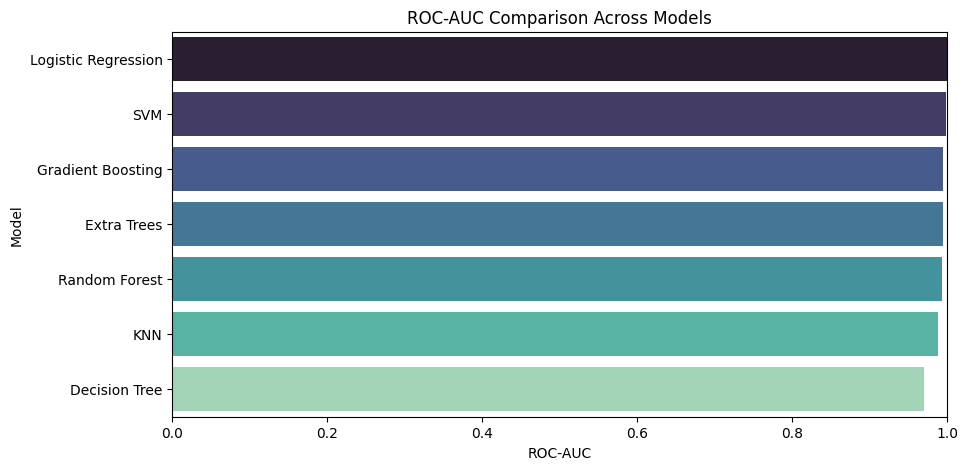

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, y="Model", x="Accuracy", palette="crest")
plt.title("Accuracy Comparison Across Models")
plt.xlim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, y="Model", x="ROC-AUC", palette="mako")
plt.title("ROC-AUC Comparison Across Models")
plt.xlim(0, 1)
plt.show()


In [30]:
from sklearn.model_selection import GridSearchCV

et_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [6, 8, 10, None],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

et_search = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_grid=et_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

et_search.fit(X_train_scaled, y_train)

best_et = et_search.best_estimator_
best_et_pred = best_et.predict(X_test_scaled)
best_et_prob = best_et.predict_proba(X_test_scaled)[:, 1]

print("Best Parameters:", et_search.best_params_)
print("Best CV ROC-AUC:", et_search.best_score_)

tuned_et_results = pd.DataFrame([{
    "Model": "Extra Trees (Tuned)",
    "Accuracy": accuracy_score(y_test, best_et_pred),
    "Precision": precision_score(y_test, best_et_pred, zero_division=0),
    "Recall": recall_score(y_test, best_et_pred, zero_division=0),
    "F1 Score": f1_score(y_test, best_et_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, best_et_prob),
    "CV ROC-AUC": et_search.best_score_
}])

tuned_et_results.round(4)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV ROC-AUC: 0.9954484209922004


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC
0,Extra Trees (Tuned),0.97,0.9544,0.9237,0.9388,0.9961,0.9954


In [32]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import numpy as np
import pandas as pd

val_prob = best_et.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold from validation set:", round(float(best_threshold), 4))

test_prob = best_et.predict_proba(X_test_scaled)[:, 1]
test_pred_default = (test_prob >= 0.5).astype(int)
test_pred_tuned = (test_prob >= best_threshold).astype(int)

threshold_df = pd.DataFrame([
    {
        "Technique": "Extra Trees tuned, default threshold 0.5",
        "Accuracy": accuracy_score(y_test, test_pred_default),
        "Precision": precision_score(y_test, test_pred_default, zero_division=0),
        "Recall": recall_score(y_test, test_pred_default, zero_division=0),
        "F1 Score": f1_score(y_test, test_pred_default, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob)
    },
    {
        "Technique": f"Extra Trees tuned, optimized threshold {best_threshold:.3f}",
        "Accuracy": accuracy_score(y_test, test_pred_tuned),
        "Precision": precision_score(y_test, test_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test, test_pred_tuned, zero_division=0),
        "F1 Score": f1_score(y_test, test_pred_tuned, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob)
    }
])

threshold_df["Accuracy Improvement"] = threshold_df["Accuracy"] - threshold_df.loc[0, "Accuracy"]
threshold_df["Recall Improvement"] = threshold_df["Recall"] - threshold_df.loc[0, "Recall"]

threshold_df.round(4)


Best threshold from validation set: 0.4933


,Technique,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Accuracy Improvement,Recall Improvement
0,"Extra Trees tuned, default threshold 0.5",0.971,0.9545,0.9277,0.9409,0.9961,0.000,0.000
1,"Extra Trees tuned, optimized threshold 0.493",0.972,0.9547,0.9317,0.9431,0.9961,0.001,0.004


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       751
           1       0.95      0.93      0.94       249

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



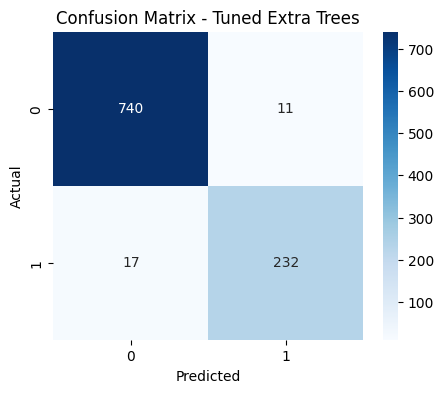

In [33]:
print("Classification Report:\n")
print(classification_report(y_test, test_pred_tuned))

cm = confusion_matrix(y_test, test_pred_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Extra Trees")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


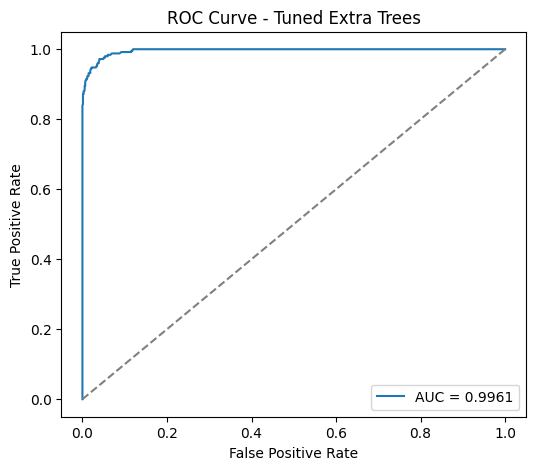

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_prob)
auc_score = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Extra Trees")
plt.legend()
plt.show()


In [35]:
logistic_row = results_df[results_df["Model"] == "Logistic Regression"].iloc[0]

summary_df = pd.DataFrame([
    {
        "Approach": "Baseline Logistic Regression",
        "Accuracy": logistic_row["Accuracy"],
        "Precision": logistic_row["Precision"],
        "Recall": logistic_row["Recall"],
        "F1 Score": logistic_row["F1 Score"],
        "ROC-AUC": logistic_row["ROC-AUC"]
    },
    {
        "Approach": "Best Untuned Model",
        "Accuracy": results_df.iloc[0]["Accuracy"],
        "Precision": results_df.iloc[0]["Precision"],
        "Recall": results_df.iloc[0]["Recall"],
        "F1 Score": results_df.iloc[0]["F1 Score"],
        "ROC-AUC": results_df.iloc[0]["ROC-AUC"]
    },
    {
        "Approach": "Tuned Extra Trees + Threshold Optimization",
        "Accuracy": accuracy_score(y_test, test_pred_tuned),
        "Precision": precision_score(y_test, test_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test, test_pred_tuned, zero_division=0),
        "F1 Score": f1_score(y_test, test_pred_tuned, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob)
    }
])

summary_df["Accuracy Improvement vs Baseline"] = summary_df["Accuracy"] - summary_df.loc[0, "Accuracy"]
summary_df["Recall Improvement vs Baseline"] = summary_df["Recall"] - summary_df.loc[0, "Recall"]
summary_df["F1 Improvement vs Baseline"] = summary_df["F1 Score"] - summary_df.loc[0, "F1 Score"]

summary_df.round(4)


,Approach,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Accuracy Improvement vs Baseline,Recall Improvement vs Baseline,F1 Improvement vs Baseline
0,Baseline Logistic Regression,0.994,0.9880,0.9880,0.9880,0.9999,0.000,0.0000,0.0000
1,Best Untuned Model,0.994,0.9880,0.9880,0.9880,0.9999,0.000,0.0000,0.0000
2,Tuned Extra Trees + Threshold Optimization,0.972,0.9547,0.9317,0.9431,0.9961,-0.022,-0.0562,-0.0449
